## ANÁLISIS MULTIVARIANTE: COVARIANZA
CESNET TIME SERIES 24 - AGGREGATION 10 MINUTE
- Sacar TOP 5 COVARIANZA
- Análisis de esos pares con ventanas deslizantes y umbrales para detectar comportamientos anómalos

In [1]:
# IMPORTS, FUNCIONES Y DIRECTORIOS

# IMPORTS
import pandas as pd
import numpy as np
import os
import tqdm
from scipy.io import savemat
import matplotlib.pyplot as plt
import ast  # Para convertir strings que representan listas a listas reales
import warnings
warnings.filterwarnings("ignore")
import skfda
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.ml.clustering import KMeans
from datetime import datetime
from datetime import date
from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.misc.metrics import lp_distance
from skfda.representation.grid import FDataGrid
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from sklearn.metrics import silhouette_score
from skfda.misc.metrics import LpDistance

# FUNCIONES
# Ajustar el eje X para mostrar fechas en lugar de segundos Unix
# a) Convertir los valores del eje x (segundos Unix) a un formato numérico
# que Matplotlib pueda interpretar como fecha (días desde el año 0)
# Esto se hace usando la función personalizada UnixConverter.
# Como FDataGrid usa los segundos directamente, la conversión
# debe hacerse en el formateador o usar una aproximación.

# En Matplotlib, `ax.xaxis.set_major_formatter()` es lo que necesitas.
# Usaremos un formateador que convierta los segundos Unix a objetos datetime.
def unix_to_date_formatter(unix_timestamp, pos):
    """
    Formateador de Matplotlib para convertir segundos Unix a fecha.
    """
    # Se añade un pequeño offset si Matplotlib lo requiere, pero generalmente
    # epoch2num es el conversor más limpio para Matplotlib.
    return pd.to_datetime(unix_timestamp, unit='s').strftime('%Y-%m-%d')
    # O para una representación de solo día/mes:
    # return pd.to_datetime(unix_timestamp, unit='s').strftime('%d %b')


def aplicar_mu_law(df, mu=255, col_time="time"):
    def transformar_columna(x):
        x_max = x.abs().max()
        if x_max == 0:
            return x

        x_norm = x / x_max
        x_mu = np.sign(x_norm) * (np.log(1 + mu * np.abs(x_norm)) / np.log(1 + mu))
        return x_mu

    # Separar time
    time = df[col_time]
    data = df.drop(columns=[col_time])

    # Aplicar Mu-Law solo a las señales
    data_mu = data.apply(transformar_columna)

    # Volver a unir time
    data_mu[col_time] = time

    return data_mu


def t_to_datetime_info(t_norm):
    """
    Convierte t ∈ [0,1] a día, hora y minuto reales
    """
    minutes_per_week = 7 * 24 * 60

    total_minutes = t_norm * minutes_per_week

    day_idx = int(total_minutes // (24 * 60))
    day_idx = min(day_idx, 6)  # seguridad numérica

    minutes_in_day = total_minutes % (24 * 60)
    hour = int(minutes_in_day // 60)
    minute = int(minutes_in_day % 60)

    days = ["Lunes", "Martes", "Miércoles",
            "Jueves", "Viernes", "Sábado", "Domingo"]

    return days[day_idx], hour, minute


def t_to_original_index(t_norm, n_points=1008):
    """
    Mapea t ∈ [0,1] al índice original más cercano
    """
    idx = int(round(t_norm * (n_points - 1)))
    return max(0, min(idx, n_points - 1))


def parse_week_column(col_name):
    """
    Ejemplo: 'n_flows_0_41_2023'
    → variable='n_flows_0', week=41, year=2023
    """
    parts = col_name.split("_")
    year = int(parts[-1])
    week = int(parts[-2])
    variable = "_".join(parts[:-2])
    return variable, week, year

def get_week_mask(df_ts, week, year):
    return (
        (df_ts.index.isocalendar().week == week) &
        (df_ts.index.isocalendar().year == year)
    )


import pywt

def compute_optimal_window(signal, wavelet='db4', max_level=6):
    coeffs = pywt.wavedec(signal, wavelet, level=max_level)

    # coeffs = [A_j, D_j, D_{j-1}, ..., D1]
    energies = []

    for i in range(1, len(coeffs)):  # solo detalles
        Dj = coeffs[i]
        energy = np.sum(Dj**2)
        energies.append(energy)

    energies = np.array(energies)

    # Normalizar energías
    energies_norm = energies / np.sum(energies)

    # Buscar el "corte": donde la energía deja de ser relevante
    threshold = np.mean(energies_norm)
    significant_levels = np.where(energies_norm > threshold)[0]

    if len(significant_levels) == 0:
        j_opt = 1
    else:
        j_opt = significant_levels[-1] + 1  # +1 porque empezamos en D1

    window_size = 2 ** j_opt

    return window_size, energies_norm


# DIRECTORIOS
DATASET_PATH = r"C:\Users\itsal\Desktop\MASTER\TFM\CESNET\CESNET_TimeSeries24"

IP_ADDRESSES_SAMPLE = os.path.join(DATASET_PATH, "ip_addresses_sample")
INSTITUTIONS = os.path.join(DATASET_PATH, "institutions")
INSTITUTION_SUBNETS = os.path.join(DATASET_PATH, "institution_subnets")
##IP_ADDRESSES_FULL = os.path.join(DATASET_PATH, "ip_addresses_full")


TIMES_10_MINUTES = os.path.join(DATASET_PATH, "times", "times_10_minutes.csv")
TIMES_1_HOUR = os.path.join(DATASET_PATH, "times", "times_1_hour.csv")
TIMES_1_DAY = os.path.join(DATASET_PATH, "times", "times_1_day.csv")


# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar
agg_1_day_path = os.path.join(INSTITUTIONS, "agg_1_day")
agg_1_hour_path = os.path.join(INSTITUTIONS, "agg_1_hour")
agg_10_minutes_path = os.path.join(INSTITUTIONS, "agg_10_minutes")
# !!!!!!!!!!!!!! INSTITUTIONS !!!!!!!!!!!!!! <- se puede cambiar

In [2]:
# VARIABLES PARA USAR
file_path = os.path.join(agg_10_minutes_path, os.listdir(agg_10_minutes_path)[0])
df_TS24 = pd.read_csv(file_path)
print(df_TS24.columns[1:].tolist())


['n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl']


In [3]:
# INSITUCIONES DISPONIBLES
csv_files = [
    f for f in os.listdir(agg_10_minutes_path)
    if f.endswith(".csv")
]

print(csv_files)



['0.csv', '1.csv', '10.csv', '100.csv', '101.csv', '102.csv', '103.csv', '104.csv', '105.csv', '106.csv', '107.csv', '108.csv', '109.csv', '11.csv', '110.csv', '111.csv', '112.csv', '113.csv', '114.csv', '115.csv', '116.csv', '117.csv', '118.csv', '119.csv', '12.csv', '120.csv', '121.csv', '122.csv', '123.csv', '124.csv', '125.csv', '126.csv', '127.csv', '128.csv', '129.csv', '13.csv', '130.csv', '131.csv', '132.csv', '133.csv', '134.csv', '135.csv', '136.csv', '137.csv', '138.csv', '139.csv', '14.csv', '140.csv', '141.csv', '142.csv', '143.csv', '144.csv', '145.csv', '146.csv', '147.csv', '148.csv', '149.csv', '15.csv', '150.csv', '151.csv', '152.csv', '153.csv', '154.csv', '155.csv', '156.csv', '157.csv', '158.csv', '159.csv', '16.csv', '160.csv', '161.csv', '162.csv', '163.csv', '164.csv', '165.csv', '166.csv', '167.csv', '168.csv', '169.csv', '17.csv', '170.csv', '171.csv', '172.csv', '173.csv', '175.csv', '176.csv', '177.csv', '178.csv', '179.csv', '18.csv', '180.csv', '181.csv', 

In [4]:
# ELECCIÓN DE INSTITUCION
institucion = "0.csv"

In [5]:
# VARIABLES + COMPANDING
# Rutas
fpath = os.path.join(agg_10_minutes_path, institucion)

# Leer mapping id_time → time
times_df = pd.read_csv(TIMES_10_MINUTES)

# Leer CSV
df_TS24_institucion = pd.read_csv(fpath)

# Merge para sustituir id_time por time
df_TS24_institucion = (
    df_TS24_institucion.merge(times_df, on="id_time", how="left")
    .drop(columns=["id_time"])
)

# Obtener automáticamente todas las variables excepto 'time'
columnas_variables = [c for c in df_TS24_institucion.columns if c != "time"]

# Renombrar dinámicamente las columnas
suffix = institucion.replace(".csv", "")
rename_dict = {c: f"{c}_{suffix}" for c in columnas_variables}

df_TS24_institucion = (
    df_TS24_institucion[["time"] + columnas_variables]
    .rename(columns=rename_dict)
)

# Convertir time a datetime y eliminar zona horaria
df_TS24_institucion["time"] = (
    pd.to_datetime(df_TS24_institucion["time"], utc=True)
    .dt.tz_localize(None)
)

# COMPANDING
df_TS24_companded = aplicar_mu_law(df_TS24_institucion)

# Reordenar columnas (time primero)
cols = ['time'] + [c for c in df_TS24_companded.columns if c != 'time']
df_TS24_companded = df_TS24_companded[cols]

df_TS24_companded

,time,n_flows_0,n_packets_0,n_bytes_0,sum_n_dest_asn_0,average_n_dest_asn_0,std_n_dest_asn_0,sum_n_dest_ports_0,average_n_dest_ports_0,std_n_dest_ports_0,sum_n_dest_ip_0,average_n_dest_ip_0,std_n_dest_ip_0,tcp_udp_ratio_packets_0,tcp_udp_ratio_bytes_0,dir_ratio_packets_0,dir_ratio_bytes_0,avg_duration_0,avg_ttl_0
0,2023-10-09 00:03:49,0.786395,0.556011,0.485229,0.937398,0.897544,0.730504,0.723815,0.654599,0.531626,0.864681,0.702225,0.539279,0.977801,0.979900,0.919263,0.921880,0.834754,0.935149
1,2023-10-09 00:13:49,0.784258,0.612719,0.557126,0.932079,0.891597,0.727349,0.724404,0.654463,0.542798,0.860106,0.696973,0.536504,0.977801,0.979900,0.923291,0.929849,0.845184,0.934073
2,2023-10-09 00:23:49,0.770960,0.529257,0.479572,0.914546,0.876341,0.715106,0.717946,0.650350,0.534171,0.844129,0.683540,0.523721,0.975423,0.975112,0.927232,0.933705,0.853158,0.925544
3,2023-10-09 00:33:49,0.771163,0.545362,0.468585,0.920799,0.883417,0.720352,0.714879,0.648117,0.531568,0.848982,0.689093,0.530359,0.975423,0.977522,0.923291,0.929849,0.852712,0.931336
4,2023-10-09 00:43:49,0.794084,0.550940,0.496169,0.932955,0.887054,0.730210,0.736435,0.661117,0.537055,0.867106,0.698678,0.544241,0.975423,0.975112,0.923291,0.929849,0.849556,0.927567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40293,2024-07-14 21:10:52,0.756735,0.665485,0.631164,0.877990,0.865853,0.687061,0.702725,0.660855,0.473715,0.822051,0.687395,0.538104,0.975423,0.972670,0.915143,0.921880,0.879931,0.917419
40294,2024-07-14 21:20:52,0.738219,0.689312,0.654781,0.866929,0.855672,0.682145,0.664181,0.623480,0.412964,0.814498,0.680854,0.527814,0.975423,0.972670,0.923291,0.925908,0.883262,0.910450
40295,2024-07-14 21:30:52,0.746981,0.732208,0.710108,0.872613,0.862217,0.698738,0.683780,0.643567,0.419075,0.815799,0.682821,0.537817,0.973013,0.970194,0.919263,0.925908,0.889381,0.909146
40296,2024-07-14 21:40:52,0.731862,0.653425,0.625553,0.863153,0.849128,0.677746,0.661649,0.618254,0.402428,0.809930,0.673634,0.523617,0.977801,0.975112,0.923291,0.929849,0.889837,0.912826


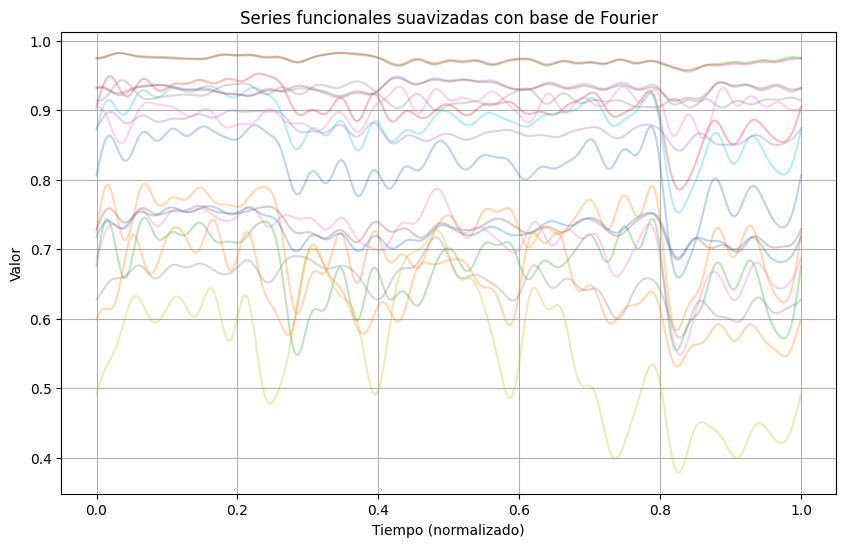

In [6]:
# TODAS LAS VARIABLES

# ---------------------------
# 1️⃣ Limpiar DataFrame
# ---------------------------
df_clean = (
    df_TS24_companded
    .interpolate(axis=0, limit_direction='both')
    .bfill()
    .ffill()
)

# ---------------------------
# 2️⃣ Quitar columna de tiempo (primera columna)
# ---------------------------
df_values = df_clean.iloc[:, 1:]   # todas excepto la primera
series_names = df_values.columns.tolist()

# ---------------------------
# 3️⃣ Crear base de Fourier
# ---------------------------
n_time = df_values.shape[0]       # número de puntos temporales
t = np.linspace(0, 1, n_time)     # dominio normalizado
n_basis = 50                    # ajustar según necesidad

basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

# ---------------------------
# 4️⃣ Convertir TODAS las columnas a representación funcional
# ---------------------------
fd = FDataGrid(
    data_matrix=df_values.T.values,  # cada fila = una serie
    grid_points=t
)

fd_basis = fd.to_basis(basis)

# ---------------------------
# 5️⃣ Evaluar funciones en la rejilla temporal
# ---------------------------
X_all = fd_basis(t).squeeze()   # shape: (n_series, n_time)

# ---------------------------
# 6️⃣ Plot opcional: todas las series suavizadas
# ---------------------------
plt.figure(figsize=(10, 6))

for serie in X_all:
    plt.plot(t, serie, alpha=0.3)

plt.xlabel("Tiempo (normalizado)")
plt.ylabel("Valor")
plt.title("Series funcionales suavizadas con base de Fourier")
plt.grid(True)
plt.show()

In [7]:
# SACAR COVARIANZA
# Convertimos a DataFrame
df_functional = pd.DataFrame(X_all.T, columns=series_names)

# =========================================================
# MATRIZ DE COVARIANZA
# =========================================================

cov_matrix = df_functional.cov()

# Formato largo
cov_df = cov_matrix.unstack().reset_index()
cov_df.columns = ['Var1', 'Var2', 'Covariance']

# Eliminar autocovarianzas
cov_df = cov_df[cov_df['Var1'] != cov_df['Var2']]

# Eliminar duplicados espejo
cov_df = cov_df[cov_df['Var1'] < cov_df['Var2']]

# =========================================================
# 🔝 TOP 10 (por magnitud, manteniendo signo)
# =========================================================

top10_cov = cov_df.loc[
    cov_df['Covariance'].abs().sort_values(ascending=False).index
].head(10)

print("Top 10 pares con mayor covarianza (positiva y negativa):")
print(top10_cov.to_string(index=False))

Top 10 pares con mayor covarianza (positiva y negativa):
                  Var1               Var2  Covariance
       std_n_dest_ip_0 std_n_dest_ports_0    0.003928
    std_n_dest_ports_0 sum_n_dest_ports_0    0.003508
average_n_dest_ports_0 std_n_dest_ports_0    0.002463
             n_bytes_0        n_packets_0    0.002442
             n_flows_0 std_n_dest_ports_0    0.002109
             n_flows_0        n_packets_0    0.002037
             n_bytes_0          n_flows_0    0.001905
       std_n_dest_ip_0 sum_n_dest_ports_0    0.001891
             n_flows_0 sum_n_dest_ports_0    0.001774
           n_packets_0    sum_n_dest_ip_0    0.001748


ANALISIS TOP 5 - COVARIANZA

In [8]:
# TOP 5
top5_cov = cov_df.loc[
    cov_df['Covariance'].abs().sort_values(ascending=False).index
].head(5)

print("Top 5 pares con mayor covarianza (positiva y negativa):")
print(top5_cov.to_string(index=False))



Top 5 pares con mayor covarianza (positiva y negativa):
                  Var1               Var2  Covariance
       std_n_dest_ip_0 std_n_dest_ports_0    0.003928
    std_n_dest_ports_0 sum_n_dest_ports_0    0.003508
average_n_dest_ports_0 std_n_dest_ports_0    0.002463
             n_bytes_0        n_packets_0    0.002442
             n_flows_0 std_n_dest_ports_0    0.002109


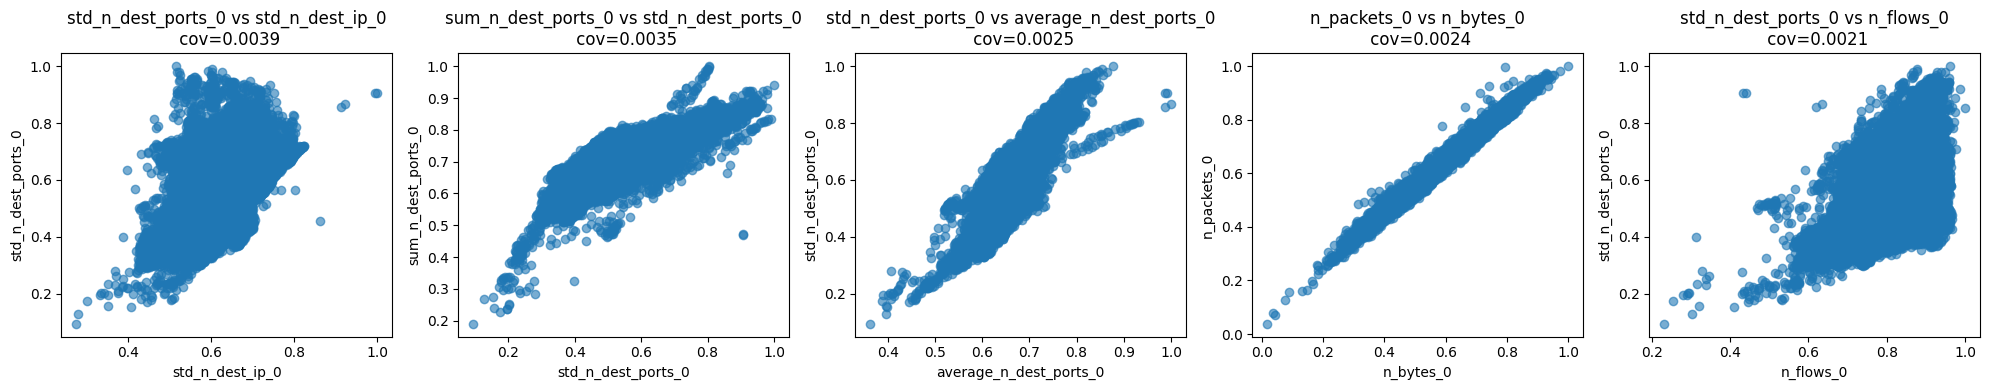

In [10]:
# SCATTER PLOT
# Crear figura con subplots (5 gráficos)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (_, row) in enumerate(top5_cov.iterrows()):

    x_var = row["Var1"]
    y_var = row["Var2"]
    cov_value = row["Covariance"]

    axes[i].scatter(
        df_TS24_companded[x_var],
        df_TS24_companded[y_var],
        alpha=0.6
    )

    axes[i].set_xlabel(x_var)
    axes[i].set_ylabel(y_var)
    axes[i].set_title(f"{y_var} vs {x_var}\n cov={cov_value:.4f}")

plt.tight_layout()

# Guardar en PDF
plt.savefig("scatter_plots_covarianza.pdf", format="pdf", bbox_inches="tight")

# Mostrar gráfico
plt.show()

In [12]:
# SEPARAR DF EN SEMANAS

# Extraer variables únicas del top5
cols_to_process = pd.unique(
    top5_cov[['Var1', 'Var2']].values.ravel()
).tolist()

# Extraer año ISO y semana ISO
iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week

weekly_data = {}

# Agrupar por año ISO y semana
for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):

    for col in cols_to_process:

        col_name = f"{col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[col].reset_index(drop=True)

df_weeks = pd.DataFrame(weekly_data)

df_weeks


,std_n_dest_ip_0_41_2023,std_n_dest_ports_0_41_2023,sum_n_dest_ports_0_41_2023,average_n_dest_ports_0_41_2023,n_bytes_0_41_2023,n_packets_0_41_2023,n_flows_0_41_2023,std_n_dest_ip_0_42_2023,std_n_dest_ports_0_42_2023,sum_n_dest_ports_0_42_2023,...,n_bytes_0_27_2024,n_packets_0_27_2024,n_flows_0_27_2024,std_n_dest_ip_0_28_2024,std_n_dest_ports_0_28_2024,sum_n_dest_ports_0_28_2024,average_n_dest_ports_0_28_2024,n_bytes_0_28_2024,n_packets_0_28_2024,n_flows_0_28_2024
0,0.539279,0.531626,0.723815,0.654599,0.485229,0.556011,0.786395,0.534435,0.875153,0.865401,...,0.440438,0.495936,0.724335,0.472202,0.364595,0.612470,0.590546,0.317787,0.380174,0.655542
1,0.536504,0.542798,0.724404,0.654463,0.557126,0.612719,0.784258,0.535763,0.896426,0.886506,...,0.467601,0.518806,0.705411,0.461078,0.407217,0.616355,0.596439,0.332872,0.400646,0.650348
2,0.523721,0.534171,0.717946,0.650350,0.479572,0.529257,0.770960,0.524650,0.952611,0.909279,...,0.354567,0.429805,0.709636,0.472202,0.459022,0.645209,0.622350,0.378880,0.433742,0.670358
3,0.530359,0.531568,0.714879,0.648117,0.468585,0.545362,0.771163,0.527578,0.919802,0.893158,...,0.490535,0.519970,0.720041,0.518506,0.422284,0.638958,0.617756,0.401267,0.453899,0.663320
4,0.544241,0.537055,0.736435,0.661117,0.496169,0.550940,0.794084,0.524341,0.968240,0.922433,...,0.445068,0.515802,0.714500,0.472065,0.367012,0.617538,0.592659,0.364405,0.422408,0.659702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,0.544611,0.783642,0.814552,0.739799,0.615759,0.647799,0.843148,0.720758,0.672538,0.742496,...,0.369390,0.444748,0.673631,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1004,0.530591,0.905717,0.877163,0.804054,0.528459,0.589268,0.887017,0.715166,0.676931,0.753717,...,0.504823,0.548486,0.653386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1005,0.546201,0.901084,0.882879,0.808262,0.561467,0.646395,0.891946,0.743529,0.705212,0.785328,...,0.319281,0.387065,0.672639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1006,0.538040,0.886530,0.873586,0.801372,0.559933,0.609552,0.883701,0.749545,0.712087,0.789548,...,0.360317,0.425893,0.656493,NaN,NaN,NaN,NaN,NaN,NaN,NaN


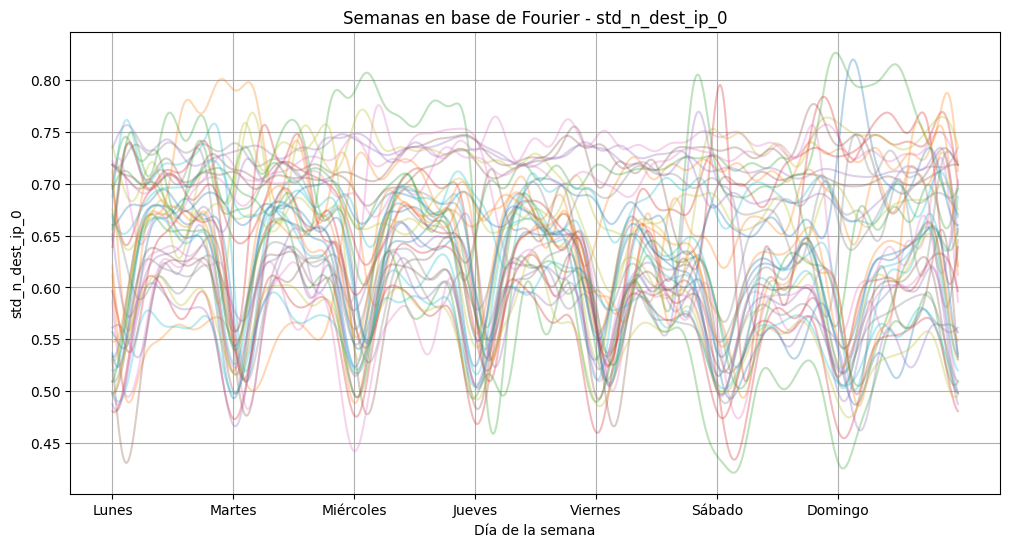

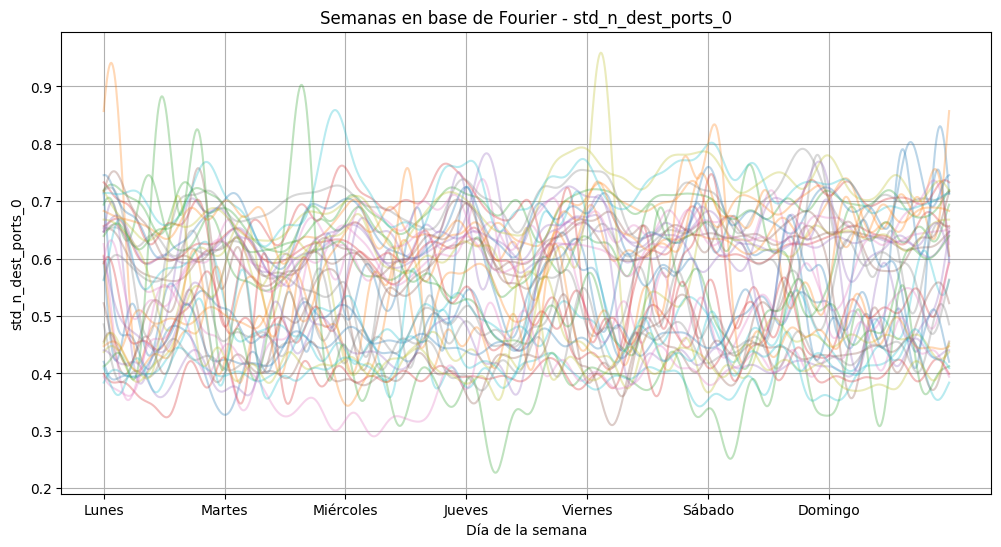

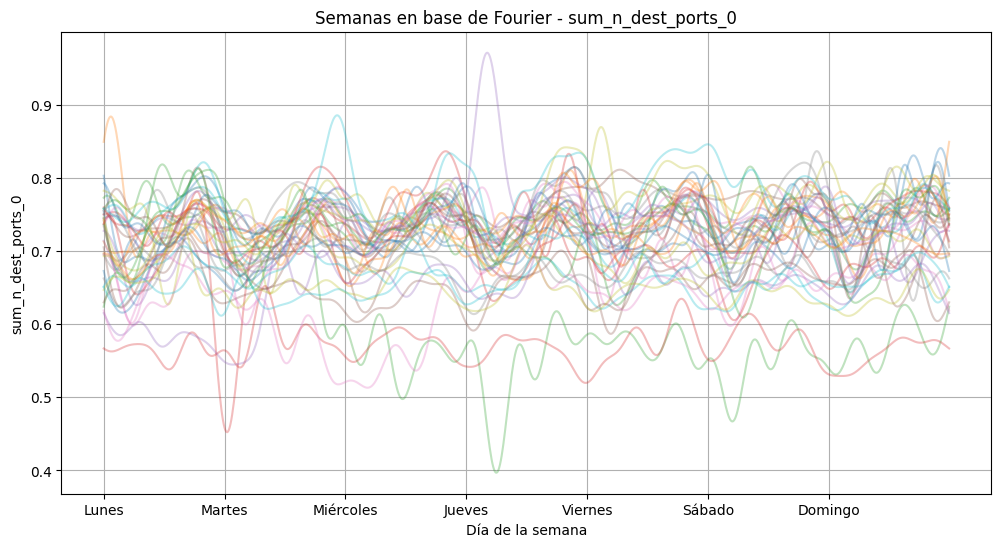

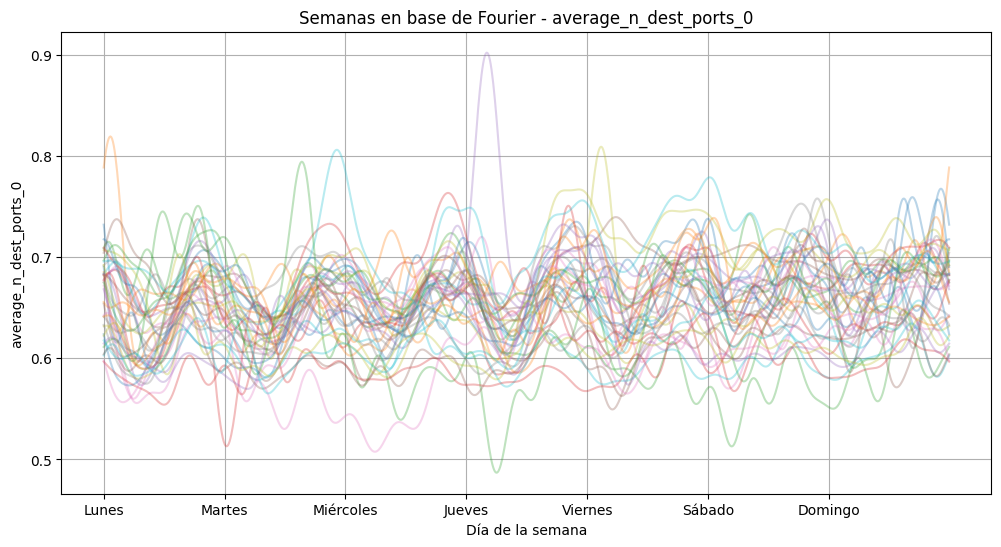

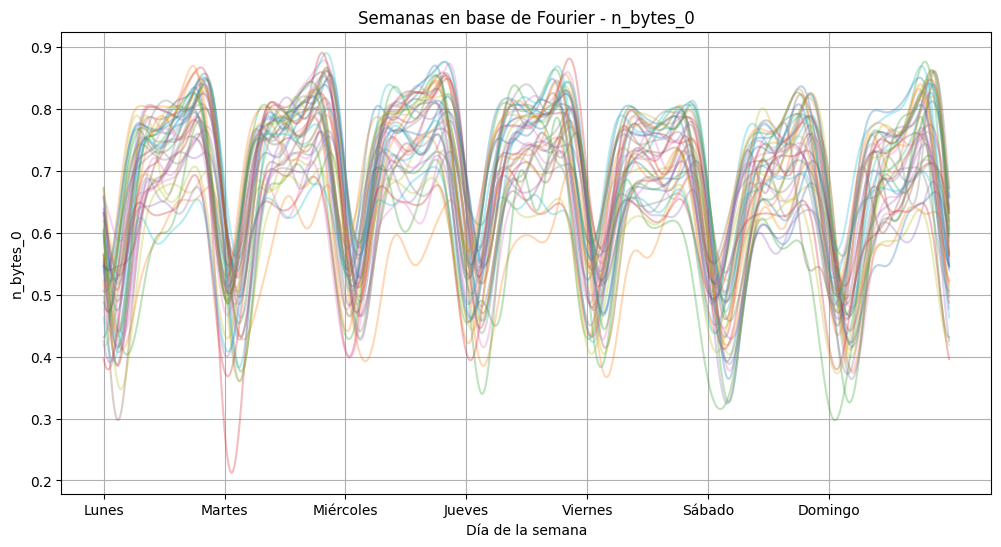

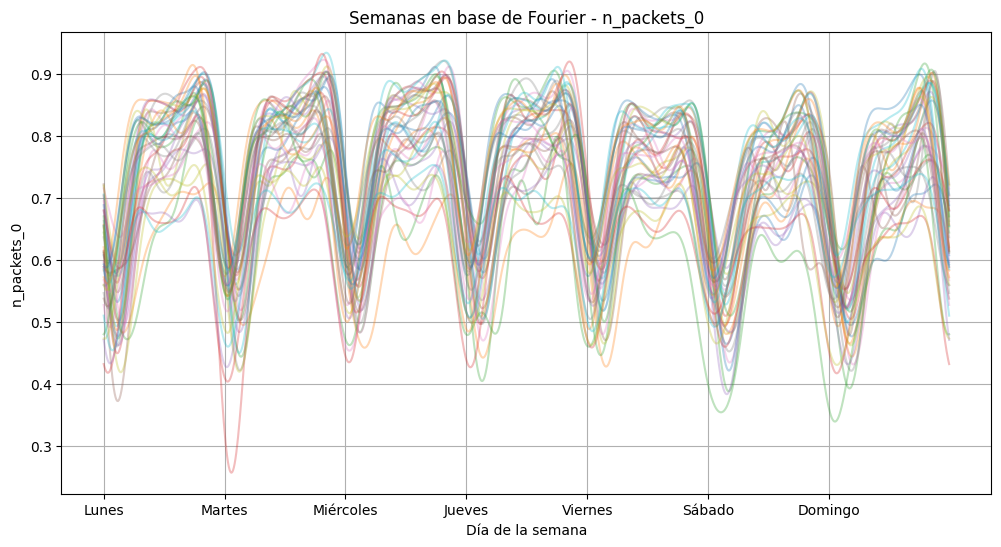

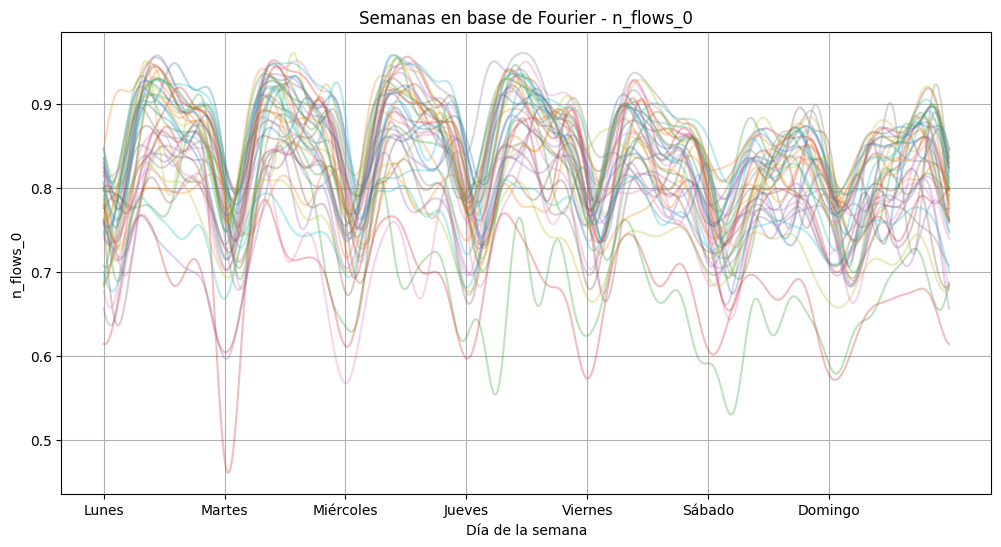

In [14]:
# PASAR A SERIES FUNCIONALES

# ==========================================================
# 1️⃣ SEPARAR DF EN SEMANAS (como ya lo tienes)
# ==========================================================

iso = df_TS24_companded['time'].dt.isocalendar()
df_TS24_companded['iso_year'] = iso.year
df_TS24_companded['iso_week'] = iso.week


weekly_data = {}

for (year, week), group in df_TS24_companded.groupby(['iso_year', 'iso_week']):
    for col in cols_to_process:
        col_name = f"{col}_{int(week):02d}_{int(year)}"
        weekly_data[col_name] = group[col].reset_index(drop=True)

df_weeks = pd.DataFrame(weekly_data)

# ==========================================================
# 2️⃣ LIMPIAR DATAFRAME
# ==========================================================

df_weeks_clean = (
    df_weeks
    .interpolate(axis=0, limit_direction='both')
    .bfill()
    .ffill()
)

# ==========================================================
# 3️⃣ DEFINIR EJE TEMPORAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

minutes_per_step = 10
x_hours = np.arange(n_time) * minutes_per_step / 60

days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ticks = np.arange(0, 7*24, 24)

# ==========================================================
# 4️⃣ PROCESAR CADA VARIABLE POR SEPARADO
# ==========================================================

n_basis = 50  # Ajustado con el codo del MSE

for col in cols_to_process:

    # Seleccionar semanas de esa variable
    col_weeks = [c for c in df_weeks_clean.columns if c.startswith(col)]
    df_var = df_weeks_clean[col_weeks]

    # Crear objeto funcional
    basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

    fd = FDataGrid(
        data_matrix=df_var.T.values,
        grid_points=t
    )

    fd_fourier = fd.to_basis(basis)

    # Evaluar en rejilla original
    X = fd_fourier(t).squeeze()

    # ======================================================
    # 5️⃣ REPRESENTACIÓN
    # ======================================================

    plt.figure(figsize=(12, 6))

    for week_curve in X:
        plt.plot(x_hours, week_curve, alpha=0.3)

    plt.title(f"Semanas en base de Fourier - {col}")
    plt.xlabel("Día de la semana")
    plt.ylabel(col)
    plt.xticks(ticks, days)
    plt.grid(True)
    plt.show()

In [15]:
# SEMANAS DISPONIBLES
groups_week = dict(
    tuple(
        df_TS24_companded.groupby(
            [
                df_TS24_companded["time"].dt.isocalendar().year,
                df_TS24_companded["time"].dt.isocalendar().week,
            ]
        )
    )
)

# Semanas disponibles (AÑO, SEMANA)
semanas_disponibles = [(int(a), int(b)) for a, b in groups_week]
print(semanas_disponibles)

[(2023, 41), (2023, 42), (2023, 43), (2023, 44), (2023, 45), (2023, 46), (2023, 47), (2023, 48), (2023, 49), (2023, 50), (2023, 51), (2023, 52), (2024, 1), (2024, 2), (2024, 3), (2024, 4), (2024, 5), (2024, 6), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17), (2024, 18), (2024, 19), (2024, 20), (2024, 21), (2024, 22), (2024, 23), (2024, 24), (2024, 25), (2024, 26), (2024, 27), (2024, 28)]


In [16]:
# ELEGIR SEMANA
selected_week = "11_2024"    

Análisis: std_n_dest_ip_0 std_n_dest_ports_0


Anomalías detectadas: 31
PDF guardado correctamente: covarianza_anomalias_std_n_dest_ip_0_std_n_dest_ports_0_semana_11_2024.pdf


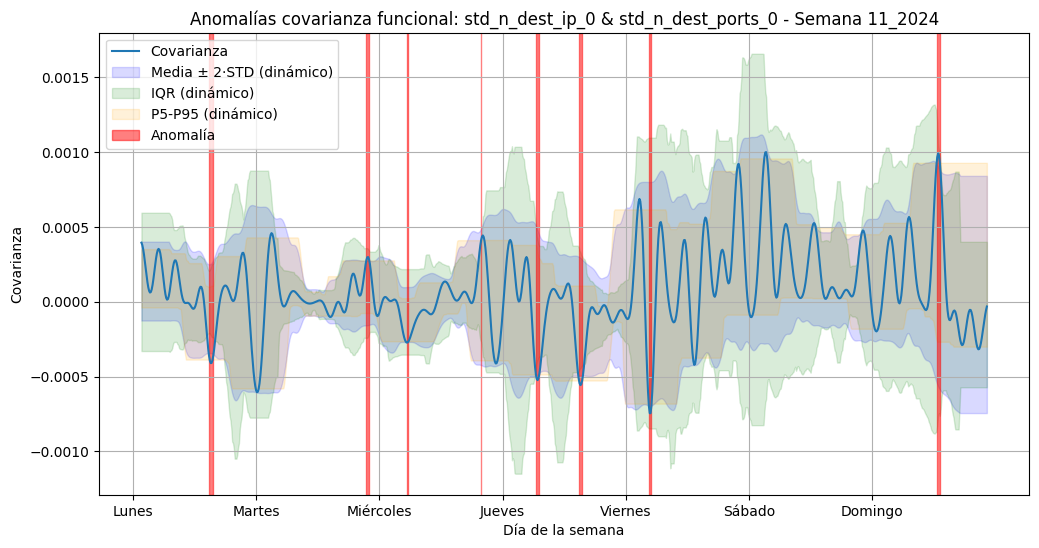

In [19]:
# CALCULO COVARIANZA Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[0]
var2 = cols_to_process[1]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 6   # inicial (luego se recalcula)
step_size = 1

k = 2
percentil_low = 5
percentil_high = 95

window_thr = 64  # ventana para umbrales dinámicos

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

n_basis = 70
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"
    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CALCULAR TAMAÑO VENTANA - WAVELETS
# ==========================================================

window_size = 20

# ==========================================================
# 🔹 COVARIANZA DESLIZANTE FUNCIONAL
# ==========================================================

covariances = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:
        cov = np.nan
    else:
        cov = np.cov(segment1, segment2)[0, 1]

    covariances.append(cov)

    # Conversión a horas
    time_centers.append((start + window_size / 2) * 10 / 60)

cov_array = np.array(covariances)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS (ROLLING)
# ==========================================================

cov_series = pd.Series(cov_array)

# Media y STD dinámicos
rolling_mean = cov_series.rolling(
    window=window_thr,
    center=True
).mean()

rolling_std = cov_series.rolling(
    window=window_thr,
    center=True
).std()

upper_std_dyn = rolling_mean + k * rolling_std
lower_std_dyn = rolling_mean - k * rolling_std

# Percentiles dinámicos
upper_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_high / 100)

lower_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_low / 100)

# IQR dinámico
Q1_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.25)

Q3_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.75)

IQR_dyn = Q3_dyn - Q1_dyn

upper_iqr_dyn = Q3_dyn + 1.5 * IQR_dyn
lower_iqr_dyn = Q1_dyn - 1.5 * IQR_dyn

# ==========================================================
# 🔹 LIMPIEZA DE NaNs
# ==========================================================

upper_std_dyn = upper_std_dyn.interpolate().bfill().ffill()
lower_std_dyn = lower_std_dyn.interpolate().bfill().ffill()

upper_iqr_dyn = upper_iqr_dyn.interpolate().bfill().ffill()
lower_iqr_dyn = lower_iqr_dyn.interpolate().bfill().ffill()

upper_p_dyn = upper_p_dyn.interpolate().bfill().ffill()
lower_p_dyn = lower_p_dyn.interpolate().bfill().ffill()

# ==========================================================
# 🔹 DETECCIÓN DE ANOMALÍAS DINÁMICA
# ==========================================================

anomalies_std = (
    (cov_series > upper_std_dyn)
    | (cov_series < lower_std_dyn)
)

anomalies_iqr = (
    (cov_series > upper_iqr_dyn)
    | (cov_series < lower_iqr_dyn)
)

anomalies_p95 = (
    (cov_series > upper_p_dyn)
    | (cov_series < lower_p_dyn)
)

anomalies_decided = (
    anomalies_std.astype(int)
    + anomalies_iqr.astype(int)
    + anomalies_p95.astype(int)
) >= 2

print("Anomalías detectadas:", np.nansum(anomalies_decided))

# ==========================================================
# 🔹 REPRESENTACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(
    time_hours,
    cov_array,
    linewidth=1.5,
    label="Covarianza"
)

# ==========================================================
# 🔹 BANDAS DINÁMICAS SOMBREADAS
# ==========================================================

# STD dinámico
ax.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    color="blue",
    alpha=0.15,
    label=f"Media ± {k}·STD (dinámico)"
)

# IQR dinámico
ax.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    color="green",
    alpha=0.15,
    label="IQR (dinámico)"
)

# Percentiles dinámicos
ax.fill_between(
    time_hours,
    lower_p_dyn,
    upper_p_dyn,
    color="orange",
    alpha=0.15,
    label=f"P{percentil_low}-P{percentil_high} (dinámico)"
)

# ==========================================================
# 🔹 BLOQUES DE ANOMALÍAS
# ==========================================================

anomaly_blocks = []
start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:
        start_idx = i

    elif not is_anomaly and start_idx is not None:
        anomaly_blocks.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    anomaly_blocks.append((start_idx, len(anomalies_decided) - 1))

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    ax.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.5,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# 🔹 FORMATO EJE
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Covarianza")

ax.set_title(
    f"Anomalías covarianza funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

ax.grid(True)
ax.legend()

# ==========================================================
# 🔹 GUARDAR EN PDF
# ==========================================================

pdf_filename = (
    f"covarianza_anomalias_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado correctamente: {pdf_filename}")

# ==========================================================
# 🔹 MOSTRAR FIGURA
# ==========================================================

plt.show()

# Opcional: cerrar figura para liberar memoria
plt.close(fig)

Análisis: std_n_dest_ports_0 sum_n_dest_ports_0

Anomalías detectadas: 50
PDF guardado correctamente: covarianza_anomalias_std_n_dest_ports_0_sum_n_dest_ports_0_semana_11_2024.pdf


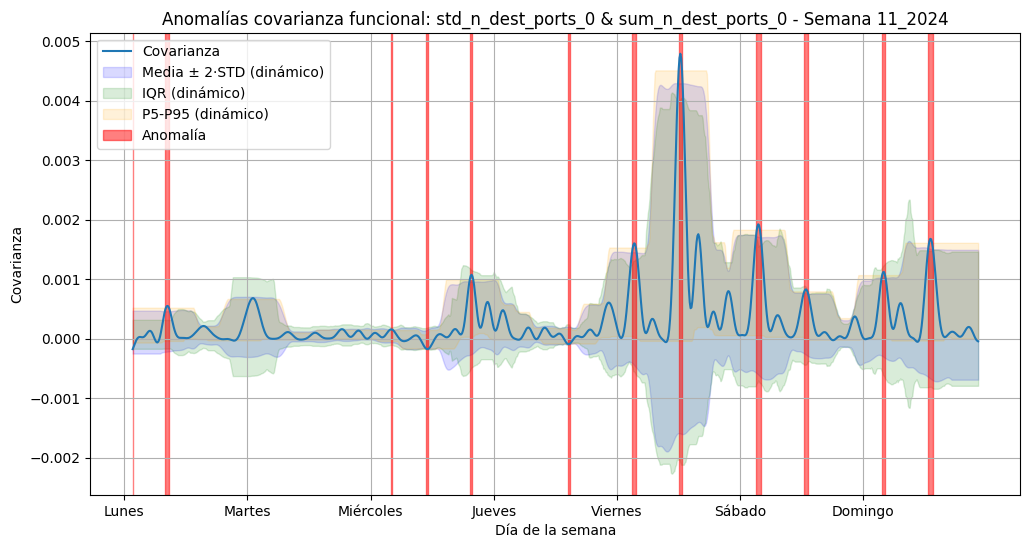

In [20]:
# CALCULO COVARIANZA Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[1]
var2 = cols_to_process[2]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 6   # inicial (luego se recalcula)
step_size = 1

k = 2
percentil_low = 5
percentil_high = 95

window_thr = 64  # ventana para umbrales dinámicos

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

n_basis = 70
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"
    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CALCULAR TAMAÑO VENTANA - WAVELETS
# ==========================================================

window_size = 20

# ==========================================================
# 🔹 COVARIANZA DESLIZANTE FUNCIONAL
# ==========================================================

covariances = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:
        cov = np.nan
    else:
        cov = np.cov(segment1, segment2)[0, 1]

    covariances.append(cov)

    # Conversión a horas
    time_centers.append((start + window_size / 2) * 10 / 60)

cov_array = np.array(covariances)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS (ROLLING)
# ==========================================================

cov_series = pd.Series(cov_array)

# Media y STD dinámicos
rolling_mean = cov_series.rolling(
    window=window_thr,
    center=True
).mean()

rolling_std = cov_series.rolling(
    window=window_thr,
    center=True
).std()

upper_std_dyn = rolling_mean + k * rolling_std
lower_std_dyn = rolling_mean - k * rolling_std

# Percentiles dinámicos
upper_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_high / 100)

lower_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_low / 100)

# IQR dinámico
Q1_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.25)

Q3_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.75)

IQR_dyn = Q3_dyn - Q1_dyn

upper_iqr_dyn = Q3_dyn + 1.5 * IQR_dyn
lower_iqr_dyn = Q1_dyn - 1.5 * IQR_dyn

# ==========================================================
# 🔹 LIMPIEZA DE NaNs
# ==========================================================

upper_std_dyn = upper_std_dyn.interpolate().bfill().ffill()
lower_std_dyn = lower_std_dyn.interpolate().bfill().ffill()

upper_iqr_dyn = upper_iqr_dyn.interpolate().bfill().ffill()
lower_iqr_dyn = lower_iqr_dyn.interpolate().bfill().ffill()

upper_p_dyn = upper_p_dyn.interpolate().bfill().ffill()
lower_p_dyn = lower_p_dyn.interpolate().bfill().ffill()

# ==========================================================
# 🔹 DETECCIÓN DE ANOMALÍAS DINÁMICA
# ==========================================================

anomalies_std = (
    (cov_series > upper_std_dyn)
    | (cov_series < lower_std_dyn)
)

anomalies_iqr = (
    (cov_series > upper_iqr_dyn)
    | (cov_series < lower_iqr_dyn)
)

anomalies_p95 = (
    (cov_series > upper_p_dyn)
    | (cov_series < lower_p_dyn)
)

anomalies_decided = (
    anomalies_std.astype(int)
    + anomalies_iqr.astype(int)
    + anomalies_p95.astype(int)
) >= 2

print("Anomalías detectadas:", np.nansum(anomalies_decided))

# ==========================================================
# 🔹 REPRESENTACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(
    time_hours,
    cov_array,
    linewidth=1.5,
    label="Covarianza"
)

# ==========================================================
# 🔹 BANDAS DINÁMICAS SOMBREADAS
# ==========================================================

# STD dinámico
ax.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    color="blue",
    alpha=0.15,
    label=f"Media ± {k}·STD (dinámico)"
)

# IQR dinámico
ax.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    color="green",
    alpha=0.15,
    label="IQR (dinámico)"
)

# Percentiles dinámicos
ax.fill_between(
    time_hours,
    lower_p_dyn,
    upper_p_dyn,
    color="orange",
    alpha=0.15,
    label=f"P{percentil_low}-P{percentil_high} (dinámico)"
)

# ==========================================================
# 🔹 BLOQUES DE ANOMALÍAS
# ==========================================================

anomaly_blocks = []
start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:
        start_idx = i

    elif not is_anomaly and start_idx is not None:
        anomaly_blocks.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    anomaly_blocks.append((start_idx, len(anomalies_decided) - 1))

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    ax.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.5,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# 🔹 FORMATO EJE
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Covarianza")

ax.set_title(
    f"Anomalías covarianza funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

ax.grid(True)
ax.legend()

# ==========================================================
# 🔹 GUARDAR EN PDF
# ==========================================================

pdf_filename = (
    f"covarianza_anomalias_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado correctamente: {pdf_filename}")

# ==========================================================
# 🔹 MOSTRAR FIGURA
# ==========================================================

plt.show()

# Opcional: cerrar figura para liberar memoria
plt.close(fig)

Análisis: average_n_dest_ports_0 std_n_dest_ports_0

Anomalías detectadas: 45
PDF guardado correctamente: covarianza_anomalias_average_n_dest_ports_0_std_n_dest_ports_0_semana_11_2024.pdf


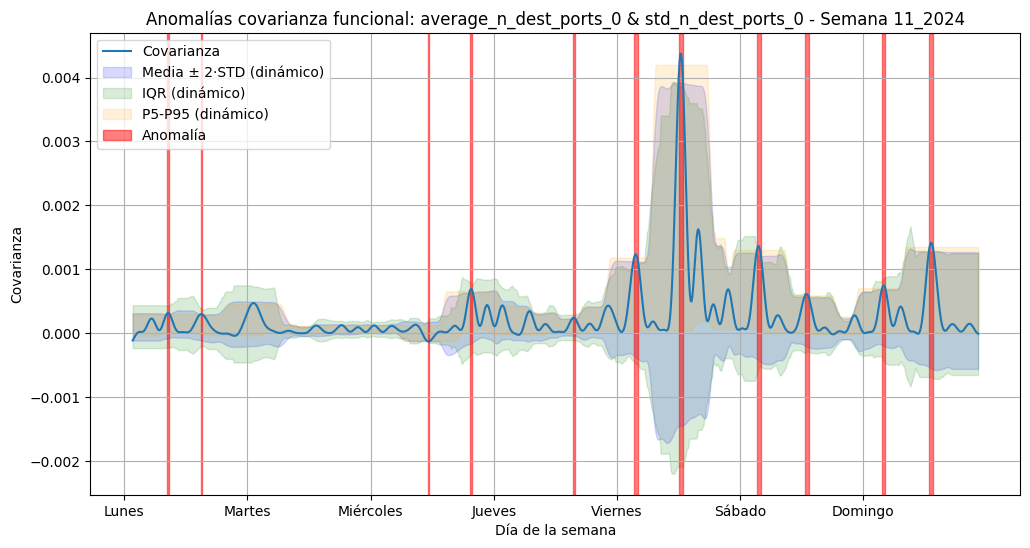

In [21]:
# CALCULO COVARIANZA Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[3]
var2 = cols_to_process[1]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 6   # inicial (luego se recalcula)
step_size = 1

k = 2
percentil_low = 5
percentil_high = 95

window_thr = 64  # ventana para umbrales dinámicos

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

n_basis = 70
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"
    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CALCULAR TAMAÑO VENTANA - WAVELETS
# ==========================================================

window_size = 20

# ==========================================================
# 🔹 COVARIANZA DESLIZANTE FUNCIONAL
# ==========================================================

covariances = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:
        cov = np.nan
    else:
        cov = np.cov(segment1, segment2)[0, 1]

    covariances.append(cov)

    # Conversión a horas
    time_centers.append((start + window_size / 2) * 10 / 60)

cov_array = np.array(covariances)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS (ROLLING)
# ==========================================================

cov_series = pd.Series(cov_array)

# Media y STD dinámicos
rolling_mean = cov_series.rolling(
    window=window_thr,
    center=True
).mean()

rolling_std = cov_series.rolling(
    window=window_thr,
    center=True
).std()

upper_std_dyn = rolling_mean + k * rolling_std
lower_std_dyn = rolling_mean - k * rolling_std

# Percentiles dinámicos
upper_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_high / 100)

lower_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_low / 100)

# IQR dinámico
Q1_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.25)

Q3_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.75)

IQR_dyn = Q3_dyn - Q1_dyn

upper_iqr_dyn = Q3_dyn + 1.5 * IQR_dyn
lower_iqr_dyn = Q1_dyn - 1.5 * IQR_dyn

# ==========================================================
# 🔹 LIMPIEZA DE NaNs
# ==========================================================

upper_std_dyn = upper_std_dyn.interpolate().bfill().ffill()
lower_std_dyn = lower_std_dyn.interpolate().bfill().ffill()

upper_iqr_dyn = upper_iqr_dyn.interpolate().bfill().ffill()
lower_iqr_dyn = lower_iqr_dyn.interpolate().bfill().ffill()

upper_p_dyn = upper_p_dyn.interpolate().bfill().ffill()
lower_p_dyn = lower_p_dyn.interpolate().bfill().ffill()

# ==========================================================
# 🔹 DETECCIÓN DE ANOMALÍAS DINÁMICA
# ==========================================================

anomalies_std = (
    (cov_series > upper_std_dyn)
    | (cov_series < lower_std_dyn)
)

anomalies_iqr = (
    (cov_series > upper_iqr_dyn)
    | (cov_series < lower_iqr_dyn)
)

anomalies_p95 = (
    (cov_series > upper_p_dyn)
    | (cov_series < lower_p_dyn)
)

anomalies_decided = (
    anomalies_std.astype(int)
    + anomalies_iqr.astype(int)
    + anomalies_p95.astype(int)
) >= 2

print("Anomalías detectadas:", np.nansum(anomalies_decided))

# ==========================================================
# 🔹 REPRESENTACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(
    time_hours,
    cov_array,
    linewidth=1.5,
    label="Covarianza"
)

# ==========================================================
# 🔹 BANDAS DINÁMICAS SOMBREADAS
# ==========================================================

# STD dinámico
ax.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    color="blue",
    alpha=0.15,
    label=f"Media ± {k}·STD (dinámico)"
)

# IQR dinámico
ax.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    color="green",
    alpha=0.15,
    label="IQR (dinámico)"
)

# Percentiles dinámicos
ax.fill_between(
    time_hours,
    lower_p_dyn,
    upper_p_dyn,
    color="orange",
    alpha=0.15,
    label=f"P{percentil_low}-P{percentil_high} (dinámico)"
)

# ==========================================================
# 🔹 BLOQUES DE ANOMALÍAS
# ==========================================================

anomaly_blocks = []
start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:
        start_idx = i

    elif not is_anomaly and start_idx is not None:
        anomaly_blocks.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    anomaly_blocks.append((start_idx, len(anomalies_decided) - 1))

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    ax.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.5,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# 🔹 FORMATO EJE
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Covarianza")

ax.set_title(
    f"Anomalías covarianza funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

ax.grid(True)
ax.legend()

# ==========================================================
# 🔹 GUARDAR EN PDF
# ==========================================================

pdf_filename = (
    f"covarianza_anomalias_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado correctamente: {pdf_filename}")

# ==========================================================
# 🔹 MOSTRAR FIGURA
# ==========================================================

plt.show()

# Opcional: cerrar figura para liberar memoria
plt.close(fig)

Análisis: n_bytes_0        n_packets_0

Anomalías detectadas: 26
PDF guardado correctamente: covarianza_anomalias_n_bytes_0_n_packets_0_semana_11_2024.pdf


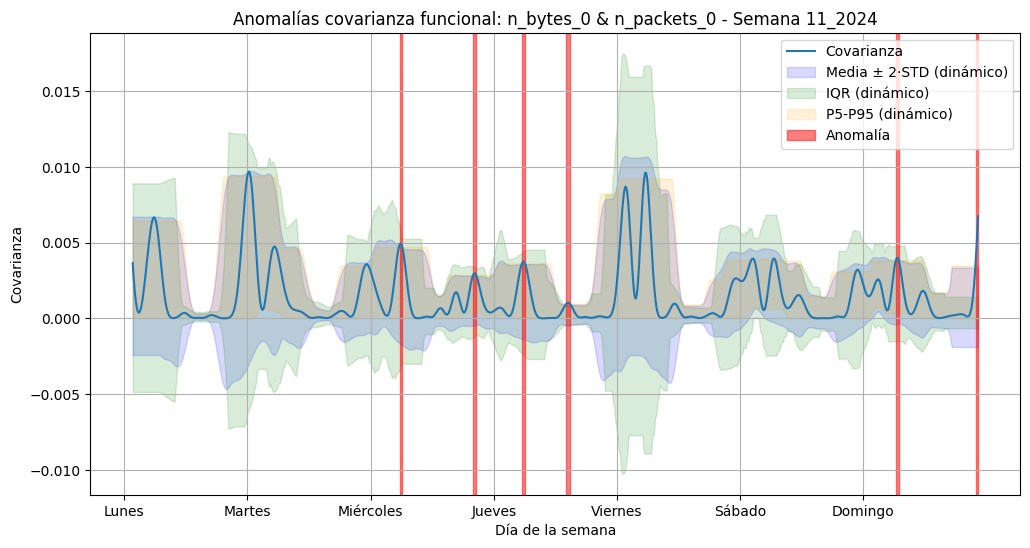

In [22]:
# CALCULO COVARIANZA Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[4]
var2 = cols_to_process[5]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 6   # inicial (luego se recalcula)
step_size = 1

k = 2
percentil_low = 5
percentil_high = 95

window_thr = 64  # ventana para umbrales dinámicos

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

n_basis = 70
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"
    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CALCULAR TAMAÑO VENTANA - WAVELETS
# ==========================================================

window_size = 20

# ==========================================================
# 🔹 COVARIANZA DESLIZANTE FUNCIONAL
# ==========================================================

covariances = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:
        cov = np.nan
    else:
        cov = np.cov(segment1, segment2)[0, 1]

    covariances.append(cov)

    # Conversión a horas
    time_centers.append((start + window_size / 2) * 10 / 60)

cov_array = np.array(covariances)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS (ROLLING)
# ==========================================================

cov_series = pd.Series(cov_array)

# Media y STD dinámicos
rolling_mean = cov_series.rolling(
    window=window_thr,
    center=True
).mean()

rolling_std = cov_series.rolling(
    window=window_thr,
    center=True
).std()

upper_std_dyn = rolling_mean + k * rolling_std
lower_std_dyn = rolling_mean - k * rolling_std

# Percentiles dinámicos
upper_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_high / 100)

lower_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_low / 100)

# IQR dinámico
Q1_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.25)

Q3_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.75)

IQR_dyn = Q3_dyn - Q1_dyn

upper_iqr_dyn = Q3_dyn + 1.5 * IQR_dyn
lower_iqr_dyn = Q1_dyn - 1.5 * IQR_dyn

# ==========================================================
# 🔹 LIMPIEZA DE NaNs
# ==========================================================

upper_std_dyn = upper_std_dyn.interpolate().bfill().ffill()
lower_std_dyn = lower_std_dyn.interpolate().bfill().ffill()

upper_iqr_dyn = upper_iqr_dyn.interpolate().bfill().ffill()
lower_iqr_dyn = lower_iqr_dyn.interpolate().bfill().ffill()

upper_p_dyn = upper_p_dyn.interpolate().bfill().ffill()
lower_p_dyn = lower_p_dyn.interpolate().bfill().ffill()

# ==========================================================
# 🔹 DETECCIÓN DE ANOMALÍAS DINÁMICA
# ==========================================================

anomalies_std = (
    (cov_series > upper_std_dyn)
    | (cov_series < lower_std_dyn)
)

anomalies_iqr = (
    (cov_series > upper_iqr_dyn)
    | (cov_series < lower_iqr_dyn)
)

anomalies_p95 = (
    (cov_series > upper_p_dyn)
    | (cov_series < lower_p_dyn)
)

anomalies_decided = (
    anomalies_std.astype(int)
    + anomalies_iqr.astype(int)
    + anomalies_p95.astype(int)
) >= 2

print("Anomalías detectadas:", np.nansum(anomalies_decided))

# ==========================================================
# 🔹 REPRESENTACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(
    time_hours,
    cov_array,
    linewidth=1.5,
    label="Covarianza"
)

# ==========================================================
# 🔹 BANDAS DINÁMICAS SOMBREADAS
# ==========================================================

# STD dinámico
ax.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    color="blue",
    alpha=0.15,
    label=f"Media ± {k}·STD (dinámico)"
)

# IQR dinámico
ax.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    color="green",
    alpha=0.15,
    label="IQR (dinámico)"
)

# Percentiles dinámicos
ax.fill_between(
    time_hours,
    lower_p_dyn,
    upper_p_dyn,
    color="orange",
    alpha=0.15,
    label=f"P{percentil_low}-P{percentil_high} (dinámico)"
)

# ==========================================================
# 🔹 BLOQUES DE ANOMALÍAS
# ==========================================================

anomaly_blocks = []
start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:
        start_idx = i

    elif not is_anomaly and start_idx is not None:
        anomaly_blocks.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    anomaly_blocks.append((start_idx, len(anomalies_decided) - 1))

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    ax.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.5,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# 🔹 FORMATO EJE
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Covarianza")

ax.set_title(
    f"Anomalías covarianza funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

ax.grid(True)
ax.legend()

# ==========================================================
# 🔹 GUARDAR EN PDF
# ==========================================================

pdf_filename = (
    f"covarianza_anomalias_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado correctamente: {pdf_filename}")

# ==========================================================
# 🔹 MOSTRAR FIGURA
# ==========================================================

plt.show()

# Opcional: cerrar figura para liberar memoria
plt.close(fig)

Análisis: n_flows_0 std_n_dest_ports_0

Anomalías detectadas: 49
PDF guardado correctamente: covarianza_anomalias_n_flows_0_std_n_dest_ports_0_semana_11_2024.pdf


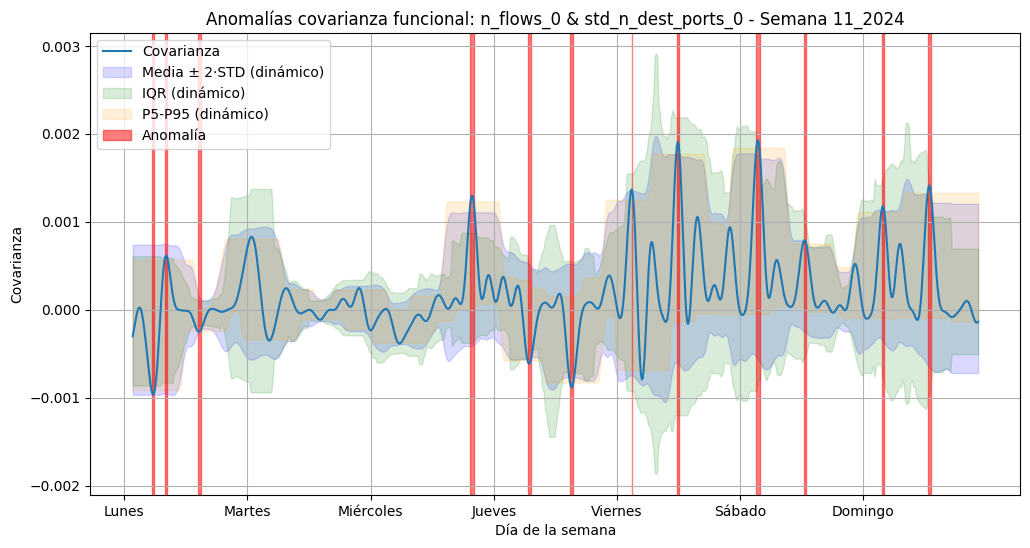

In [23]:
# CALCULO COVARIANZA Y ANOMALIAS (VENTANA 1h = 6 puntos)
# ==========================================================
# 🔹 ELECCIÓN SEMANA Y VARIABLES
# ==========================================================

var1 = cols_to_process[6]
var2 = cols_to_process[1]

# ==========================================================
# 🔹 PARÁMETROS
# ==========================================================

window_size = 6   # inicial (luego se recalcula)
step_size = 1

k = 2
percentil_low = 5
percentil_high = 95

window_thr = 64  # ventana para umbrales dinámicos

# ==========================================================
# 🔹 IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

# ==========================================================
# 🔹 OBTENER SERIES EN BASE FUNCIONAL
# ==========================================================

n_time = df_weeks_clean.shape[0]
t = np.linspace(0, 1, n_time)

n_basis = 70
basis = FourierBasis(domain_range=(0, 1), n_basis=n_basis)

def get_functional_series(col):

    col_name = f"{col}_{selected_week}"
    y = df_weeks_clean[col_name].values

    fd = FDataGrid(
        data_matrix=y.reshape(1, -1),
        grid_points=t
    )

    fd_basis = fd.to_basis(basis)

    return fd_basis(t).flatten()

y1 = get_functional_series(var1)
y2 = get_functional_series(var2)

# ==========================================================
# 🔹 CALCULAR TAMAÑO VENTANA - WAVELETS
# ==========================================================

window_size = 20

# ==========================================================
# 🔹 COVARIANZA DESLIZANTE FUNCIONAL
# ==========================================================

covariances = []
time_centers = []

n = len(y1)

for start in range(0, n - window_size + 1, step_size):

    end = start + window_size

    segment1 = y1[start:end]
    segment2 = y2[start:end]

    if np.std(segment1) == 0 or np.std(segment2) == 0:
        cov = np.nan
    else:
        cov = np.cov(segment1, segment2)[0, 1]

    covariances.append(cov)

    # Conversión a horas
    time_centers.append((start + window_size / 2) * 10 / 60)

cov_array = np.array(covariances)
time_hours = np.array(time_centers)

# ==========================================================
# 🔹 UMBRALES DINÁMICOS (ROLLING)
# ==========================================================

cov_series = pd.Series(cov_array)

# Media y STD dinámicos
rolling_mean = cov_series.rolling(
    window=window_thr,
    center=True
).mean()

rolling_std = cov_series.rolling(
    window=window_thr,
    center=True
).std()

upper_std_dyn = rolling_mean + k * rolling_std
lower_std_dyn = rolling_mean - k * rolling_std

# Percentiles dinámicos
upper_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_high / 100)

lower_p_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(percentil_low / 100)

# IQR dinámico
Q1_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.25)

Q3_dyn = cov_series.rolling(
    window_thr,
    center=True
).quantile(0.75)

IQR_dyn = Q3_dyn - Q1_dyn

upper_iqr_dyn = Q3_dyn + 1.5 * IQR_dyn
lower_iqr_dyn = Q1_dyn - 1.5 * IQR_dyn

# ==========================================================
# 🔹 LIMPIEZA DE NaNs
# ==========================================================

upper_std_dyn = upper_std_dyn.interpolate().bfill().ffill()
lower_std_dyn = lower_std_dyn.interpolate().bfill().ffill()

upper_iqr_dyn = upper_iqr_dyn.interpolate().bfill().ffill()
lower_iqr_dyn = lower_iqr_dyn.interpolate().bfill().ffill()

upper_p_dyn = upper_p_dyn.interpolate().bfill().ffill()
lower_p_dyn = lower_p_dyn.interpolate().bfill().ffill()

# ==========================================================
# 🔹 DETECCIÓN DE ANOMALÍAS DINÁMICA
# ==========================================================

anomalies_std = (
    (cov_series > upper_std_dyn)
    | (cov_series < lower_std_dyn)
)

anomalies_iqr = (
    (cov_series > upper_iqr_dyn)
    | (cov_series < lower_iqr_dyn)
)

anomalies_p95 = (
    (cov_series > upper_p_dyn)
    | (cov_series < lower_p_dyn)
)

anomalies_decided = (
    anomalies_std.astype(int)
    + anomalies_iqr.astype(int)
    + anomalies_p95.astype(int)
) >= 2

print("Anomalías detectadas:", np.nansum(anomalies_decided))

# ==========================================================
# 🔹 REPRESENTACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Serie principal
ax.plot(
    time_hours,
    cov_array,
    linewidth=1.5,
    label="Covarianza"
)

# ==========================================================
# 🔹 BANDAS DINÁMICAS SOMBREADAS
# ==========================================================

# STD dinámico
ax.fill_between(
    time_hours,
    lower_std_dyn,
    upper_std_dyn,
    color="blue",
    alpha=0.15,
    label=f"Media ± {k}·STD (dinámico)"
)

# IQR dinámico
ax.fill_between(
    time_hours,
    lower_iqr_dyn,
    upper_iqr_dyn,
    color="green",
    alpha=0.15,
    label="IQR (dinámico)"
)

# Percentiles dinámicos
ax.fill_between(
    time_hours,
    lower_p_dyn,
    upper_p_dyn,
    color="orange",
    alpha=0.15,
    label=f"P{percentil_low}-P{percentil_high} (dinámico)"
)

# ==========================================================
# 🔹 BLOQUES DE ANOMALÍAS
# ==========================================================

anomaly_blocks = []
start_idx = None

for i, is_anomaly in enumerate(anomalies_decided):

    if is_anomaly and start_idx is None:
        start_idx = i

    elif not is_anomaly and start_idx is not None:
        anomaly_blocks.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    anomaly_blocks.append((start_idx, len(anomalies_decided) - 1))

for idx, (start, end) in enumerate(anomaly_blocks):

    x_start = time_hours[start]
    x_end = time_hours[end]

    ax.axvspan(
        x_start,
        x_end,
        color="red",
        alpha=0.5,
        label="Anomalía" if idx == 0 else None
    )

# ==========================================================
# 🔹 FORMATO EJE
# ==========================================================

ticks = np.arange(0, 7 * 24, 24)

days = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

ax.set_xticks(ticks)
ax.set_xticklabels(days)

ax.set_xlabel("Día de la semana")
ax.set_ylabel("Covarianza")

ax.set_title(
    f"Anomalías covarianza funcional: "
    f"{var1} & {var2} - Semana {selected_week}"
)

ax.grid(True)
ax.legend()

# ==========================================================
# 🔹 GUARDAR EN PDF
# ==========================================================

pdf_filename = (
    f"covarianza_anomalias_"
    f"{var1}_{var2}_semana_{selected_week}.pdf"
)

with PdfPages(pdf_filename) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

print(f"PDF guardado correctamente: {pdf_filename}")

# ==========================================================
# 🔹 MOSTRAR FIGURA
# ==========================================================

plt.show()

# Opcional: cerrar figura para liberar memoria
plt.close(fig)